In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Завантажуємо всі 3 файли
uploaded = files.upload()

Saving combats.csv to combats.csv
Saving pokemon.csv to pokemon.csv
Saving tests.csv to tests.csv


In [2]:
data = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')
tests = pd.read_csv('tests.csv')

print("Pokemon shape:", data.shape)
print("Combats shape:", combats.shape)
print("Tests shape:", tests.shape)

Pokemon shape: (800, 12)
Combats shape: (50000, 3)
Tests shape: (10000, 2)


In [3]:
# Перші 5 рядків
print("=== HEAD ===")
data.head()

=== HEAD ===


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [4]:
# Останні 5 рядків
print("=== TAIL ===")
data.tail()

=== TAIL ===


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True
799,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True


In [5]:
# Назви колонок
print("=== COLUMNS ===")
print(data.columns)

=== COLUMNS ===
Index(['#', 'Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk',
       'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')


In [6]:
# Розмір датасету
print("=== SHAPE ===")
print(data.shape)  # (рядки, колонки)

=== SHAPE ===
(800, 12)


In [7]:
# Інформація про типи даних і пропуски
print("=== INFO ===")
data.info()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [8]:
# Частота типів покемонів
print("=== Частота Type 1 ===")
print(data['Type 1'].value_counts(dropna=False))

=== Частота Type 1 ===
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64


In [9]:
# Статистика по числових колонках
print("=== DESCRIBE ===")
data.describe()

=== DESCRIBE ===


,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


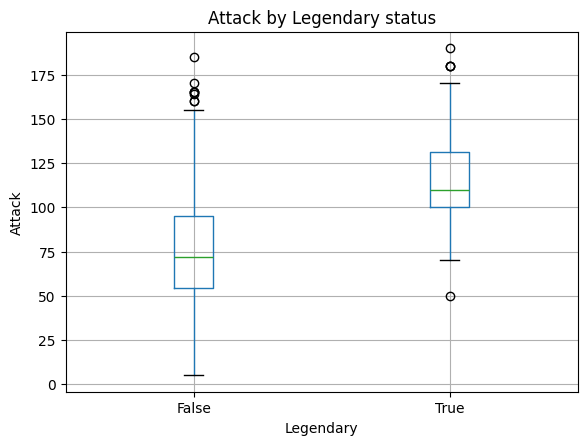

In [10]:
# Boxplot: Attack для легендарних vs звичайних покемонів
data.boxplot(column='Attack', by='Legendary')
plt.title('Attack by Legendary status')
plt.suptitle('')
plt.xlabel('Legendary')
plt.ylabel('Attack')
plt.show()

In [11]:
# Беремо тільки перші 5 рядків для прикладу
data_new = data.head()

# Melt: розплавляємо Attack і Defense в один стовпець
melted = pd.melt(frame=data_new, id_vars='Name', value_vars=['Attack', 'Defense'])
print(melted)

            Name variable  value
0      Bulbasaur   Attack     49
1        Ivysaur   Attack     62
2       Venusaur   Attack     82
3  Mega Venusaur   Attack    100
4     Charmander   Attack     52
5      Bulbasaur  Defense     49
6        Ivysaur  Defense     63
7       Venusaur  Defense     83
8  Mega Venusaur  Defense    123
9     Charmander  Defense     43


In [12]:
# Pivot: повертаємо до вихідного вигляду
pivoted = melted.pivot(index='Name', columns='variable', values='value')
print(pivoted)

variable       Attack  Defense
Name                          
Bulbasaur          49       49
Charmander         52       43
Ivysaur            62       63
Mega Venusaur     100      123
Venusaur           82       83


In [13]:
# Об'єднання рядків (axis=0)
data1 = data.head()
data2 = data.tail()
conc_rows = pd.concat([data1, data2], axis=0, ignore_index=True)
print("=== Concat по рядках ===")
print(conc_rows)

=== Concat по рядках ===
     #            Name   Type 1  Type 2  HP  Attack  Defense  Sp. Atk  \
0    1       Bulbasaur    Grass  Poison  45      49       49       65   
1    2         Ivysaur    Grass  Poison  60      62       63       80   
2    3        Venusaur    Grass  Poison  80      82       83      100   
3    4   Mega Venusaur    Grass  Poison  80     100      123      122   
4    5      Charmander     Fire     NaN  39      52       43       60   
5  796         Diancie     Rock   Fairy  50     100      150      100   
6  797    Mega Diancie     Rock   Fairy  50     160      110      160   
7  798  Hoopa Confined  Psychic   Ghost  80     110       60      150   
8  799   Hoopa Unbound  Psychic    Dark  80     160       60      170   
9  800       Volcanion     Fire   Water  80     110      120      130   

   Sp. Def  Speed  Generation  Legendary  
0       65     45           1      False  
1       80     60           1      False  
2      100     80           1      False  

In [14]:
# Об'єднання колонок (axis=1)
col1 = data['Attack'].head()
col2 = data['Defense'].head()
conc_cols = pd.concat([col1, col2], axis=1)
print("=== Concat по колонках ===")
print(conc_cols)

=== Concat по колонках ===
   Attack  Defense
0      49       49
1      62       63
2      82       83
3     100      123
4      52       43


In [15]:
print("=== Типи ДО конвертації ===")
print(data.dtypes)

# Конвертуємо Type 1 з object → category
data['Type 1'] = data['Type 1'].astype('category')

# Конвертуємо Speed з int → float
data['Speed'] = data['Speed'].astype('float')

print("\n=== Типи ПІСЛЯ конвертації ===")
print(data.dtypes)

=== Типи ДО конвертації ===
#              int64
Name          object
Type 1        object
Type 2        object
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object

=== Типи ПІСЛЯ конвертації ===
#                int64
Name            object
Type 1        category
Type 2          object
HP               int64
Attack           int64
Defense          int64
Sp. Atk          int64
Sp. Def          int64
Speed          float64
Generation       int64
Legendary         bool
dtype: object


In [16]:
# Перевіряємо пропуски
print("=== Info (перевірка пропусків) ===")
data.info()

=== Info (перевірка пропусків) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   #           800 non-null    int64   
 1   Name        799 non-null    object  
 2   Type 1      800 non-null    category
 3   Type 2      414 non-null    object  
 4   HP          800 non-null    int64   
 5   Attack      800 non-null    int64   
 6   Defense     800 non-null    int64   
 7   Sp. Atk     800 non-null    int64   
 8   Sp. Def     800 non-null    int64   
 9   Speed       800 non-null    float64 
 10  Generation  800 non-null    int64   
 11  Legendary   800 non-null    bool    
dtypes: bool(1), category(1), float64(1), int64(7), object(2)
memory usage: 64.9+ KB


In [17]:
# Кількість NaN по Type 2
print("=== Value counts Type 2 (з NaN) ===")
print(data['Type 2'].value_counts(dropna=False))

=== Value counts Type 2 (з NaN) ===
Type 2
NaN         386
Flying       97
Ground       35
Poison       34
Psychic      33
Fighting     26
Grass        25
Fairy        23
Steel        22
Dark         20
Dragon       18
Ice          14
Rock         14
Water        14
Ghost        14
Fire         12
Electric      6
Normal        4
Bug           3
Name: count, dtype: int64


In [18]:
# Заповнюємо NaN словом 'empty'
data['Type 2'].fillna('empty', inplace=True)

# Перевірка через assert
assert data['Type 2'].notnull().all()
print("✅ Пропусків більше немає!")

✅ Пропусків більше немає!


In [19]:
# Створюємо DataFrame зі словника
country = ["Spain", "France"]
population = ["11", "12"]
list_label = ["country", "population"]
list_col = [country, population]
zipped = list(zip(list_label, list_col))
data_dict = dict(zipped)
df = pd.DataFrame(data_dict)

# Додаємо нові колонки
df["capital"] = ["madrid", "paris"]
df["income"] = 0  # Broadcasting

print(df)

  country population capital  income
0   Spain         11  madrid       0
1  France         12   paris       0


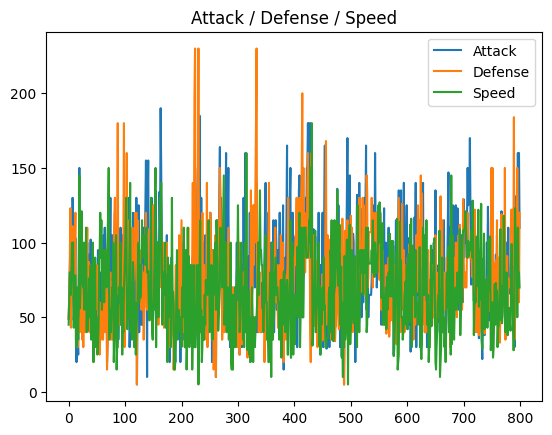

In [20]:
# Лінійний графік Attack, Defense, Speed
data1 = data.loc[:, ["Attack", "Defense", "Speed"]]
data1.plot()
plt.title("Attack / Defense / Speed")
plt.show()

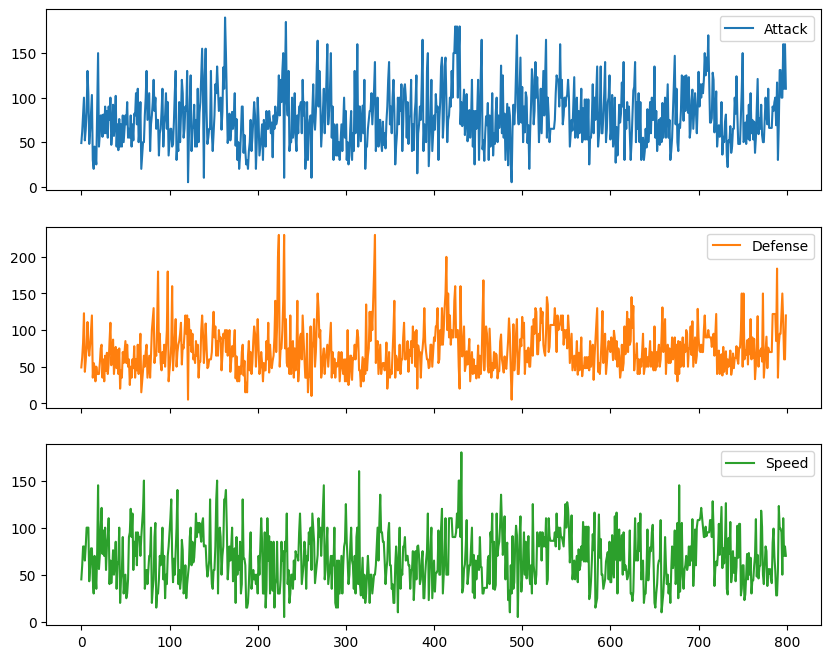

In [21]:
# Subplots окремо для кожного показника
data1.plot(subplots=True, figsize=(10, 8))
plt.show()

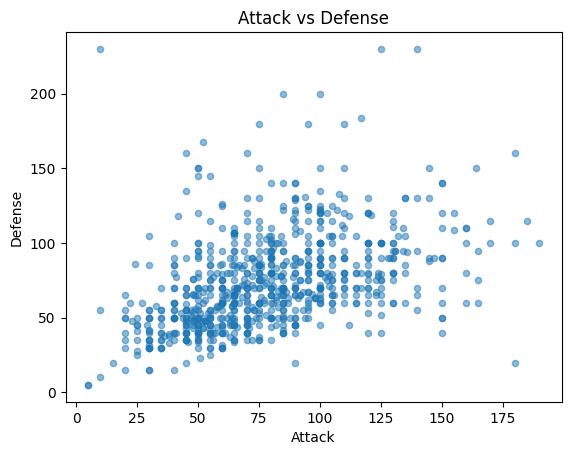

In [22]:
# Scatter plot: Attack vs Defense
data1.plot(kind="scatter", x="Attack", y="Defense", alpha=0.5)
plt.title("Attack vs Defense")
plt.show()

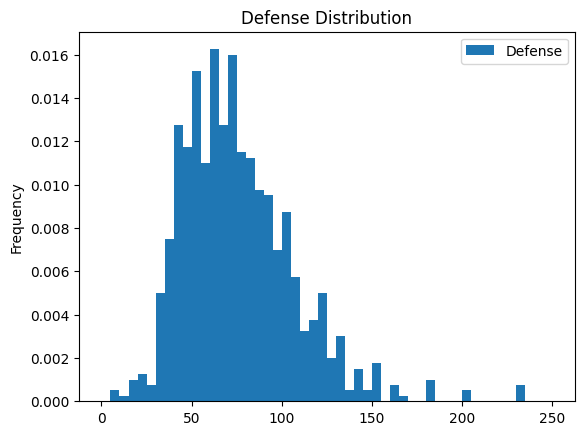

In [23]:
# Гістограма Defense
data1.plot(kind="hist", y="Defense", bins=50, range=(0, 250), density=True)
plt.title("Defense Distribution")
plt.show()

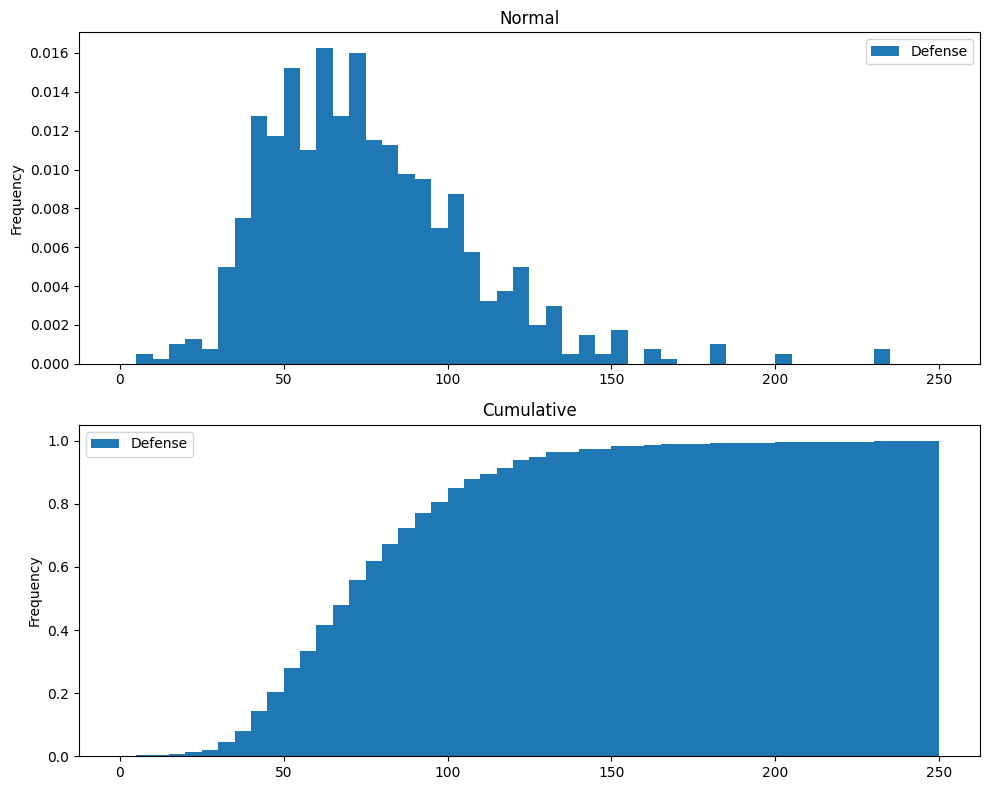

In [24]:
# Гістограма: звичайна + кумулятивна
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
data1.plot(kind="hist", y="Defense", bins=50, range=(0, 250),
           density=True, ax=axes[0], title="Normal")
data1.plot(kind="hist", y="Defense", bins=50, range=(0, 250),
           density=True, ax=axes[1], cumulative=True, title="Cumulative")
plt.tight_layout()
plt.show()

In [25]:
# Створюємо часовий ряд
data2 = data.head().copy()
date_list = ["1992-01-10", "1992-02-10", "1992-03-10", "1993-03-15", "1993-03-16"]
data2["date"] = pd.to_datetime(date_list)
data2 = data2.set_index("date")

# Вибірка по даті
print("=== Один рядок по даті ===")
print(data2.loc["1993-03-16"])

print("\n=== Діапазон дат ===")
print(data2.loc["1992-03-10":"1993-03-16"])

=== Один рядок по даті ===
#                      5
Name          Charmander
Type 1              Fire
Type 2             empty
HP                    39
Attack                52
Defense               43
Sp. Atk               60
Sp. Def               50
Speed               65.0
Generation             1
Legendary          False
Name: 1993-03-16 00:00:00, dtype: object

=== Діапазон дат ===
            #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  \
date                                                                        
1992-03-10  3       Venusaur  Grass  Poison  80      82       83      100   
1993-03-15  4  Mega Venusaur  Grass  Poison  80     100      123      122   
1993-03-16  5     Charmander   Fire   empty  39      52       43       60   

            Sp. Def  Speed  Generation  Legendary  
date                                               
1992-03-10      100   80.0           1      False  
1993-03-15      120   80.0           1      False  
1993-03-16      

In [26]:
# Resample по роках
print("=== Середнє по роках ===")
print(data2.resample("A").mean())

=== Середнє по роках ===


TypeError: category dtype does not support aggregation 'mean'

In [27]:
# Створюємо часовий ряд тільки з числових колонок
data2 = data.head().copy()
date_list = ["1992-01-10", "1992-02-10", "1992-03-10", "1993-03-15", "1993-03-16"]
data2["date"] = pd.to_datetime(date_list)
data2 = data2.set_index("date")

# Вибираємо тільки числові колонки для resample
data2_numeric = data2.select_dtypes(include='number')

# Вибірка по даті (з повного data2)
print("=== Один рядок по даті ===")
print(data2.loc["1993-03-16"])

print("\n=== Діапазон дат ===")
print(data2.loc["1992-03-10":"1993-03-16"])

=== Один рядок по даті ===
#                      5
Name          Charmander
Type 1              Fire
Type 2             empty
HP                    39
Attack                52
Defense               43
Sp. Atk               60
Sp. Def               50
Speed               65.0
Generation             1
Legendary          False
Name: 1993-03-16 00:00:00, dtype: object

=== Діапазон дат ===
            #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  \
date                                                                        
1992-03-10  3       Venusaur  Grass  Poison  80      82       83      100   
1993-03-15  4  Mega Venusaur  Grass  Poison  80     100      123      122   
1993-03-16  5     Charmander   Fire   empty  39      52       43       60   

            Sp. Def  Speed  Generation  Legendary  
date                                               
1992-03-10      100   80.0           1      False  
1993-03-15      120   80.0           1      False  
1993-03-16      

In [28]:
# Resample по роках (тільки числові колонки)
print("=== Середнє по роках ===")
print(data2_numeric.resample("YE").mean())

=== Середнє по роках ===
              #         HP     Attack  Defense    Sp. Atk    Sp. Def  \
date                                                                   
1992-12-31  2.0  61.666667  64.333333     65.0  81.666667  81.666667   
1993-12-31  4.5  59.500000  76.000000     83.0  91.000000  85.000000   

                Speed  Generation  
date                               
1992-12-31  61.666667         1.0  
1993-12-31  72.500000         1.0  


In [29]:
# Resample по місяцях з інтерполяцією
print("=== По місяцях з interpolate ===")
print(data2_numeric.resample("ME").mean().interpolate("linear"))

=== По місяцях з interpolate ===
                #         HP  Attack  Defense  Sp. Atk  Sp. Def   Speed  \
date                                                                      
1992-01-31  1.000  45.000000    49.0     49.0    65.00    65.00  45.000   
1992-02-29  2.000  60.000000    62.0     63.0    80.00    80.00  60.000   
1992-03-31  3.000  80.000000    82.0     83.0   100.00   100.00  80.000   
1992-04-30  3.125  78.291667    81.5     83.0    99.25    98.75  79.375   
1992-05-31  3.250  76.583333    81.0     83.0    98.50    97.50  78.750   
1992-06-30  3.375  74.875000    80.5     83.0    97.75    96.25  78.125   
1992-07-31  3.500  73.166667    80.0     83.0    97.00    95.00  77.500   
1992-08-31  3.625  71.458333    79.5     83.0    96.25    93.75  76.875   
1992-09-30  3.750  69.750000    79.0     83.0    95.50    92.50  76.250   
1992-10-31  3.875  68.041667    78.5     83.0    94.75    91.25  75.625   
1992-11-30  4.000  66.333333    78.0     83.0    94.00    90.00  75